# ZIP demo

This notebook follows the original ZIP script structure.


In [1]:
import os
from pathlib import Path
import sys
import importlib.util

# Set your OpenAI key here before running.
os.environ["OPENAI_API_KEY"] ='your-openai-api-key'

CURRENT_DIR = Path.cwd().resolve()

def find_src_dir(start_dir):
    for parent in [start_dir] + list(start_dir.parents):
        src_candidate = parent / "src"
        if src_candidate.exists() and (src_candidate / "creating_perturbations.py").exists():
            return src_candidate
    raise FileNotFoundError(
        "Could not find src/creating_perturbations.py. "
        "Make sure your notebook is inside the project folder."
    )

SRC_DIR = find_src_dir(CURRENT_DIR)
REPO_ROOT = SRC_DIR.parent

print("REPO_ROOT:", REPO_ROOT)
print("SRC_DIR:", SRC_DIR)

sys.path.insert(0, str(SRC_DIR))

# Helper to load modules from src
def load_module(module_name, file_path):
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

creating_perturbations = load_module(
    "creating_perturbations_mod",
    SRC_DIR / "creating_perturbations.py"
)

creating_sample = load_module(
    "creating_sample_mod",
    SRC_DIR / "creating_sample.py"
)

original_reprompting = load_module(
    "original_reprompting_mod",
    SRC_DIR / "original_reprompting.py"
)

perterbation_results = load_module(
    "perterbation_results_mod",
    SRC_DIR / "perterbation_results.py"
)

zip_calc = load_module(
    "zip_calc_mod",
    SRC_DIR / "ZIP.py"
)

stat_calc = load_module(
    "stat_calc_mod",
    SRC_DIR / "stat.py"
)

visualization = load_module(
    "visualization_mod",
    SRC_DIR / "visualization.py"
)


WORK_DIR = REPO_ROOT / "outputs" 
WORK_DIR.mkdir(parents=True, exist_ok=True)

# Set the prompt you want to test here.
ZEROSHOT_PROMPT = "Let's think step-by-step."

# choose the model for perturbation generation and answer generation.
MODEL_PERT = "gpt-4"
MODEL_ANS = "gpt-4o-mini"

REPO_ROOT: /local/home/ngsadr/Projects/clean_scripts
SRC_DIR: /local/home/ngsadr/Projects/clean_scripts/src


I0000 00:00:1779060969.861630 2824140 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779060969.862611 2824140 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779060970.971880 2824140 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779060970.972547 2824140 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 1. Create an sample

The repo includes a tiny AQUA-RAT sample so the demo is immediately runnable. You can create a larger sample or replace it with a custom dataset.

In [2]:
sample_file = WORK_DIR / 'sample_df.csv'
local_sample = REPO_ROOT / 'data' / 'aqua-rat_questions.csv'

sample_df = creating_sample.create_aqua_sample(
    output_path=str(sample_file),
    sample_size=5,
    local_sample_path=str(local_sample),
)
sample_df[['question', 'options', 'correct']]

,question,options,correct
0,Mr. X died when his age was 1/59th of year of ...,"['A)1947', 'B)1948', 'C)1980', 'D)2000', 'E)19...",A
1,Every day a cyclist meets a train at a particu...,"['A)60 kmph', 'B)65 kmph', 'C)68 kmph', 'D)70 ...",A
2,A rectangular piece of cloth 2 feet wide was c...,"['A)6', 'B)18', 'C)24', 'D)36', 'E)48']",C
3,"Let A, B and C denote the vertices of a triang...","['A)5.5', 'B)6', 'C)7', 'D)8', 'E)8.25']",B
4,The average age of the first seven people to a...,"['A)94', 'B)95', 'C)96', 'D)97', 'E)98']",B


## 2. Generate prompt perturbations

This creates deletion, synonym, and co-hyponym perturbations. For a quick demo, `n_per_method=3`. Increase it for a fuller experiment.

In [3]:
perturbations_file = WORK_DIR / "perturbations.csv"

perturbations_df = creating_perturbations.save_perturbations(
    prompt=ZEROSHOT_PROMPT,
    output_path=str(perturbations_file),
    model=MODEL_PERT,
    n_per_method=3,
    validate=True,
)

perturbations_df

,token_index,token,0,1,2,3,4,5
0,0,Let's,think step-by-step.,We should think step-by-step.,Allow us to think step-by-step.,We can think step-by-step.,We could think step-by-step.,We might think step-by-step.
1,1,think,Let's contemplate step-by-step.,Let's reflect step-by-step.,Let's analyze step-by-step.,Let's ponder step-by-step.,NaN,NaN
2,2,step-by-step.,Let's think,Let's think methodically.,NaN,NaN,NaN,NaN


## 3. Run the original prompt

The original prompt is run multiple times to estimate normal model variation.

In [4]:
samples_dir = WORK_DIR / 'Samples'

original_outputs = original_reprompting.generate_answers(
    api_key=None,
    zeroshot_prompt=ZEROSHOT_PROMPT,
    sample_file=str(sample_file),
    output_dir=str(samples_dir),
    repetitions=3,
    model=MODEL_ANS,
    temperature=0.5,
)
original_outputs[0][['question', 'gpt_answers']]

Original prompt repetitions:   0%|          | 0/3 [00:00<?, ?it/s]

Repetition 1/3:   0%|          | 0/5 [00:00<?, ?it/s]

,question,gpt_answers
0,Mr. X died when his age was 1/59th of year of ...,Let's denote Mr. X's year of birth as \( Y \) ...
1,Every day a cyclist meets a train at a particu...,Let's denote the speed of the train as \( v_t ...
2,A rectangular piece of cloth 2 feet wide was c...,Let's denote the length of the original piece ...
3,"Let A, B and C denote the vertices of a triang...",Let's denote the area of triangle \( ABC \) as...
4,The average age of the first seven people to a...,"To solve the problem, let's break it down step..."


## 4. Run perturbed prompts

For each token perturbation, the model answers the same questions.

In [5]:
perturbed_dir = WORK_DIR / 'Saved'

perturbed_files = perterbation_results.generate_answers(
    api_key=None,
    sample_file=str(sample_file),
    perturbations_file=str(perturbations_file),
    output_dir=str(perturbed_dir),
    model=MODEL_ANS,
    temperature=0.5,
    skip_stopwords=True,
)

len(perturbed_files)

Perturbed tokens:   0%|          | 0/3 [00:00<?, ?it/s]

Perturbed prompt variants:   0%|          | 0/12 [00:00<?, ?it/s]

T0 A0:   0%|          | 0/5 [00:00<?, ?it/s]

T0 A1:   0%|          | 0/5 [00:00<?, ?it/s]

T0 A2:   0%|          | 0/5 [00:00<?, ?it/s]

...

T1 A2:   0%|          | 0/5 [00:00<?, ?it/s]

T1 A3:   0%|          | 0/5 [00:00<?, ?it/s]

T2 A0:   0%|          | 0/5 [00:00<?, ?it/s]

T2 A1:   0%|          | 0/5 [00:00<?, ?it/s]

12

## 5. Compute ZIP scores

A higher ZIP score means perturbing that token changed the model's final answer more often.

In [6]:
zip_output_dir = WORK_DIR

scores_df, details_df = zip_calc.compute_zip_scores(
    samples_dir=str(samples_dir),
    perturbed_dir=str(perturbed_dir),
    perturbations_file=str(perturbations_file),
    output_dir=str(zip_output_dir),
    repetitions=3,
)

scores_df.sort_values("zip_score", ascending=False)

,token_index,token,zip_score,n_alternatives
1,1,think,55.0,4
2,2,step-by-step.,50.0,2
0,0,Let's,40.0,6


## 6. Statistical test and important words

This compares perturbation disagreement to the natural disagreement between repeated original-prompt runs.

In [7]:
zip_details_file = WORK_DIR / "zip_details.csv"
original_disagreements_file = WORK_DIR / "original_disagreements.csv"

stats_df = stat_calc.compute_significance(
    zip_details_file=str(zip_details_file),
    original_disagreements_file=str(original_disagreements_file),
    output_dir=str(WORK_DIR),
    alpha=0.05,
)

stats_df

,token_index,token,mean_perturbed_disagreement,mean_original_disagreement,statistic,p_value,significant
0,0,Let's,2.00,1.5,0.833333,0.404657,False
1,1,think,2.75,1.5,1.620185,0.105193,False
2,2,step-by-step.,2.50,1.5,1.161895,0.245278,False


## 7. Visualize ZIP scores

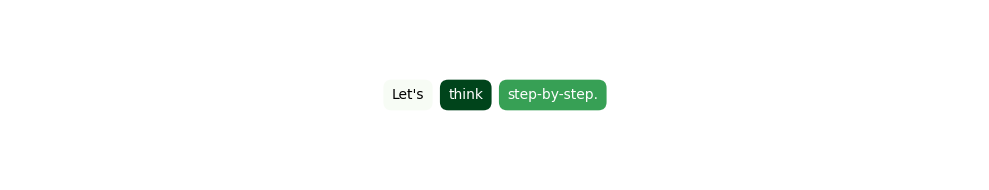

In [8]:
zip_scores_file = WORK_DIR / "zip_scores.csv"
significant_tokens_file = WORK_DIR / "significant_tokens.txt"

fig = visualization.plot_zip_heatmap(
    prompt=ZEROSHOT_PROMPT,
    zip_scores_file=str(zip_scores_file),
    significant_tokens_file=str(significant_tokens_file),
    output_path=str(WORK_DIR / "zip_heatmap.png"),
    show=True,
)